In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

c:\Users\rishi\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("merged_audio_features.csv")

# Identify the column that contains class labels (you may need to adjust this if the column name is different)
# Let's assume the column name is 'label'
class_column = 'label'  # Modify this if the actual column name is different

# Split the dataset into training and testing while maintaining 75% for training and 25% for testing
train_data = []
test_data = []

# Split by class label to ensure 75% of each class goes into the training set
for label in df[class_column].unique():
    # Filter data for this specific label
    class_data = df[df[class_column] == label]
    
    # Split the class data (75% for training and 25% for testing)
    train_class, test_class = train_test_split(class_data, test_size=0.25, random_state=42)
    
    # Append to the respective lists
    train_data.append(train_class)
    test_data.append(test_class)

# Concatenate the training and testing data
train_df = pd.concat(train_data)
test_df = pd.concat(test_data)

# Shuffle the data (optional but recommended for randomness)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to CSV files
train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

print("Data has been successfully split and saved into 'train_data.csv' and 'test_data.csv'.")


Data has been successfully split and saved into 'train_data.csv' and 'test_data.csv'.


In [3]:
class SpeechFeatureDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

        # Encode string labels into integers
        self.label_encoder = LabelEncoder()
        self.df['label'] = self.label_encoder.fit_transform(self.df['label'])

        # Store the label mapping
        self.label_map = dict(zip(self.label_encoder.classes_, self.label_encoder.transform(self.label_encoder.classes_)))

        # Extract labels
        self.labels = self.df['label'].values.astype(int)

        # Extract features and normalize
        self.feature_df = self.df.drop(columns=['file_name', 'label'])
        self.feature_names = self.feature_df.columns.tolist()
        self.feature_df = (self.feature_df - self.feature_df.mean()) / (self.feature_df.std() + 1e-8)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        features = self.feature_df.iloc[idx].values.astype(np.float32)
        label = self.labels[idx]
        return torch.tensor(features), torch.tensor(label, dtype=torch.long)


In [4]:
# CNN-LSTM-RNN Model
class CNN_LSTM_RNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(CNN_LSTM_RNN, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.lstm = nn.LSTM(input_size=64, hidden_size=128, num_layers=1, batch_first=True)
        self.rnn = nn.RNN(input_size=128, hidden_size=64, num_layers=1, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, features)
        x = self.cnn(x)     # (batch, channels, features)
        x = x.permute(0, 2, 1)  # (batch, sequence_len, features)
        x, _ = self.lstm(x)
        x, _ = self.rnn(x)
        x = x[:, -1, :]  # Last time step
        out = self.fc(x)
        return out

In [5]:
# Training function
def train_model(model, dataloader, criterion, optimizer, device, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for features, labels in dataloader:
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataloader)}")


In [6]:
# Main execution
if __name__ == "__main__":
    
    batch_size = 32
    num_epochs = 400
    learning_rate = 0.001

    csv_path = r"train_data.csv" 
    csv_path1 = r"test_data.csv" 
    dataset = SpeechFeatureDataset(csv_path)
    dataset1 = SpeechFeatureDataset(csv_path1)

    num_classes = len(dataset.label_map)

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    dataloader1 = DataLoader(dataset1, batch_size=batch_size, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    input_dim = dataset[0][0].shape[0]

    model = CNN_LSTM_RNN(input_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_model(model, dataloader, criterion, optimizer, device, num_epochs)


Epoch [1/400], Loss: 0.563742215640812
Epoch [2/400], Loss: 0.4495737857467406
Epoch [3/400], Loss: 0.3571992382345358
Epoch [4/400], Loss: 0.2830066775508936
Epoch [5/400], Loss: 0.23118626104505477
Epoch [6/400], Loss: 0.20094225639902458
Epoch [7/400], Loss: 0.18410111687830127
Epoch [8/400], Loss: 0.16316267854584326
Epoch [9/400], Loss: 0.14562147413863497
Epoch [10/400], Loss: 0.12970200673139876
Epoch [11/400], Loss: 0.11926533485843928
Epoch [12/400], Loss: 0.10774034471637511
Epoch [13/400], Loss: 0.09914149133067315
Epoch [14/400], Loss: 0.09383098640154537
Epoch [15/400], Loss: 0.08292770389606596
Epoch [16/400], Loss: 0.07721699020077563
Epoch [17/400], Loss: 0.07299817855739425
Epoch [18/400], Loss: 0.06342668755328248
Epoch [19/400], Loss: 0.06270623086257046
Epoch [20/400], Loss: 0.05236356458189526
Epoch [21/400], Loss: 0.05668359203861893
Epoch [22/400], Loss: 0.05120314545789347
Epoch [23/400], Loss: 0.04899705966691346
Epoch [24/400], Loss: 0.04948900018106659
Epoch 

In [7]:
print(dataset.label_map)  # Example: {'healthy': 0, 'impaired': 1, 'severe': 2}

{'dysarthria': 0, 'healthy': 1, 'hyperkinetic dysphonia': 2, 'hypokinetic dysphonia': 3, 'reflux laryngitis': 4}


In [8]:
print(dataset1.label_map)  # Example: {'healthy': 0, 'impaired': 1, 'severe': 2}

{'dysarthria': 0, 'healthy': 1, 'hyperkinetic dysphonia': 2, 'hypokinetic dysphonia': 3, 'reflux laryngitis': 4}


In [9]:
dataset.df.shape

(15404, 326)

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def test_model(model, test_loader, device, label_encoder):
    model.eval()  # Set the model to evaluation mode (important!)
    all_preds = []
    all_labels = []

    with torch.no_grad():  # No gradient tracking during testing
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)  # Get predicted class
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Decode numeric predictions back to label names (optional)
    all_preds_decoded = label_encoder.inverse_transform(all_preds)
    all_labels_decoded = label_encoder.inverse_transform(all_labels)

    # Print performance
    print("Classification Report:")
    print(classification_report(all_labels_decoded, all_preds_decoded))

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels_decoded, all_preds_decoded))

    

    sns.heatmap(confusion_matrix(all_labels_decoded, all_preds_decoded), annot=True, fmt='d')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Classification Report:
                        precision    recall  f1-score   support

            dysarthria       0.96      0.97      0.96      2864
               healthy       0.95      0.94      0.95      2234
hyperkinetic dysphonia       0.47      0.44      0.46        18
 hypokinetic dysphonia       0.56      0.45      0.50        11
     reflux laryngitis       0.27      0.30      0.29        10

              accuracy                           0.95      5137
             macro avg       0.64      0.62      0.63      5137
          weighted avg       0.95      0.95      0.95      5137

Confusion Matrix:
[[2772   92    0    0    0]
 [ 124 2102    5    1    2]
 [   0    3    8    2    5]
 [   0    3    2    5    1]
 [   0    4    2    1    3]]


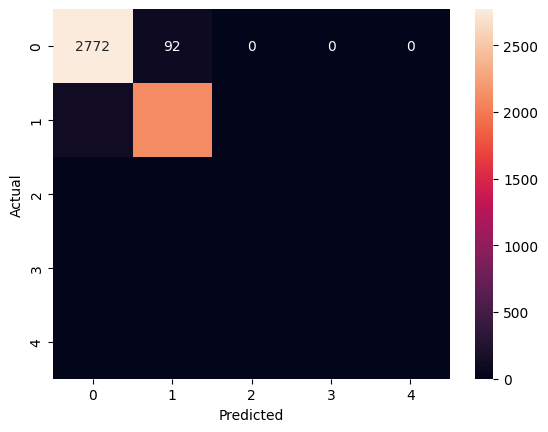

In [11]:
test_model(model, dataloader1, device, dataset1.label_encoder)


In [12]:
# Save the model
torch.save(model.state_dict(), "cnn_lstm_rnn_model.pth")
print("Model has been saved successfully!")


Model has been saved successfully!


In [13]:
# Initialize the model
model = CNN_LSTM_RNN(input_dim, num_classes).to(device)

# Load the saved model's state dictionary
model.load_state_dict(torch.load("cnn_lstm_rnn_model.pth"))
#model.eval()  # Set the model to evaluation mode


<All keys matched successfully>